# Tutorial 6 — From the structured-jet chain to detection forecasts

This notebook loads the converged **Tutorial 2** chain, generates a full catalogue,
applies the prompt sensitivities, adds the BNS parameters, runs GWFish, and computes
the X-ray afterglows. Set the chain path and simulation duration below, then **Run All**.
The jet fraction comes from the retained chain.

The default merger-rate file and jet structure match Tutorial 2. For a Tutorial 2.1
chain, point `CHAIN_PATH` to that run and set `STRUCTURE_CSV` to its structure file.
Keep `forecast_pipeline.py` beside the notebook in `Tutorials/`.

In your MAGGPY environment, install the additional tools if needed:

```bash
python -m pip install VegasAfterglow==2.0.4 joblib PyYAML lalsuite matplotlib ipykernel
python -m pip install "GWFish @ git+https://github.com/janosch314/GWFish.git"
```

In [47]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from dataclasses import asdict
import sys

import emcee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from maggpy.structured_jet.init import initialize_simulation, load_custom_structure_constants

ROOT = Path.cwd().resolve()
if ROOT.name == 'Tutorials': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'Tutorials'))
import forecast_pipeline as fp

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.2})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Settings

`CHAIN_PATH` points to the `emcee.h5` saved by Tutorial 2. `BURN_IN` is the number
of steps to discard. Keep `MRD_PATH` and `STRUCTURE_CSV` consistent with the fitted run.
`N_YEARS` is the physical duration of the generated catalogue.

In [58]:
CHAIN_PATH      = ROOT / 'Tutorials' / 'Output_files' / 'tutorial2_structured' / 'emcee.h5'
BURN_IN         = 300
N_YEARS         = 4 # for testing
DATA_DIR        = ROOT / 'datafiles'
MRD_PATH        = DATA_DIR / 'MRD_outputs' / 'fiducial_A1_0_BNS.csv'
STRUCTURE_CSV   = None      # Tutorial 2; for 2.1 use DATA_DIR / 'structure_constants/struct_results_100.csv'
THETA_V_MAX_DEG = 30.
SEED            = 42
N_JOBS          = 4               # Set to 1 for a serial run.
OUTPUT_DIR = ROOT / 'Output_files' / 'tutorial6_forecasts'

# FOV of 8 str out of 4 * pi
FOV_8sr_fraction = 8. / (4 * np.pi)

#PROMPT = (
#    fp.PromptInstrument('GRINTA_TED', (50., 300.), 1., 0.32 * 3/5, 'ph', 0.5*FOV_8sr_fraction), #5sigma it's already so high but we'll keep this number 
#    fp.PromptInstrument('Crystal_Eye', (50., 300.), 2, 0.180, 'ph', 0.3), #3sigma
#    fp.PromptInstrument('THESEUS_XGIS', (30., 150.), 1., 3e-8, 'erg', 0.16 * 0.65, 15., 0.9), #3sigma
#) use 5 sigma instead of what is written here
PROMPT = (
    fp.PromptInstrument('GRINTA_TED', (50., 300.), 1., 0.3, 'ph', 0.5*FOV_8sr_fraction), #5sigma 
    fp.PromptInstrument('Crystal_Eye', (50., 300.), 2, 0.180 / 3 * 5, 'ph', 0.3), #3sigma to 5sigma
    fp.PromptInstrument('THESEUS_XGIS', (30., 150.), 1., 3e-8 / 3 * 5, 'erg', 0.16 * 0.65, 15., 0.9), #3sigma
)
MAX_PEAK_TIME_S = None      # Tutorial peak-time cut; set None for flux-only selection.

NETWORKS = {
    'Asharp'        : ['LLO_sharp', 'LHO_sharp', 'LIO_sharp'],
    'ET_2L'         : ['ETS_15', 'ETN_15'],
    'ET_triangle'   : ['ET'],
}
WAVEFORM = 'IMRPhenomD_NRTidalv2'    # Or 'TaylorF2'.
GW_SNR_THRESHOLD = 8.
LOCALIZATION_CUTS_DEG2 = (1., 10., 100., 1000.)

AFTERGLOW_IMAGERS = fp.DEFAULT_AFTERGLOW
RESPONSE_DELAYS_S = (0., 100., 300., 3600.)
LOCALIZATION_PLOT_CUT_DEG2 = 100.
AFTERGLOW_THETA_CORE_DEG = 5.
AFTERGLOW_MAX_VIEWING_ANGLE_DEG = 10.

## 2. Load the chain and initialize the fitted population

Use the component-wise median of the retained chain, including $f_j$.

In [59]:
backend = emcee.backends.HDFBackend(str(CHAIN_PATH), read_only=True)
chain = backend.get_chain(discard=BURN_IN, flat=True)
theta = np.median(chain, axis=0)
parameter_names = ['k', 'L_L0', 'L_mu_E', 'sigma_E', 'L_mu_tau', 'sigma_tau', 'f_j']
fitted_parameters = pd.Series(theta, index=parameter_names, name='fitted value')
display(fitted_parameters.to_frame())

simulation, interps, _ = initialize_simulation(
    DATA_DIR, MRD_PATH, params={'theta_v_max': THETA_V_MAX_DEG}, size_test=30_000)
if STRUCTURE_CSV is not None:
    simulation = load_custom_structure_constants(simulation, STRUCTURE_CSV)
simulation.rng = np.random.default_rng(SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fitted_parameters.to_csv(OUTPUT_DIR / 'fitted_parameters.csv')

,fitted value
k,3.687700
L_L0,-0.827366
L_mu_E,3.467122
sigma_E,0.379286
L_mu_tau,-0.610128
sigma_tau,0.727274
f_j,0.679574


## 3. Generate the full catalogue and observables

Sample all jet sources over `N_YEARS` within the chosen viewing-angle range,
using the fitted population and MAGGPY's spectral and temporal model. The catalogue
includes redshift, viewing angle, peak energy, flux, fluence, duration and intrinsic
isotropic energy. Generation runs in small batches to limit memory use.

Instrument coverage is applied in the next step, so every annual rate is simply
the selected number of events divided by `N_YEARS`.

In [60]:
catalogue = fp.make_full_catalogue(theta, simulation, interps, years=N_YEARS)
catalogue.to_csv(OUTPUT_DIR / 'full_catalogue.csv', index=False)
display(catalogue.head())

Generating 130,574 sources for 4 years; f_j = 0.68


/mnt/c/Users/Ludovico/Desktop/CodeCleanup/MAGGPY/Tutorials/forecast_pipeline.py:81: RuntimeWarning: invalid value encountered in log
  class BandIntegrals:


,event_id,z,theta_v_rad,theta_v_deg,Ep_keV,Ep_onaxis_rest_keV,F_p_real,F_p_real_erg,peak64_ph_50_300,fluence_50_300_erg_cm2,t_peak_s,T90_s,E_iso_onaxis_erg,E_iso_structure_erg,alpha_e,alpha_n
0,0,1.124356,0.514013,29.450771,-0.732996,1298.043705,-7.723048e-19,NaN,-4.737259e-19,-5.801996e-25,0.082771,82.771281,1.075213e+51,-1.617749e+46,0.304028,0.504760
1,1,2.562967,0.506259,29.006500,-0.596178,2796.287618,-3.198689e-20,NaN,-2.908873e-20,-1.005534e-25,0.353183,353.182814,1.386744e+51,-1.824298e+46,0.307286,0.508610
2,2,1.117739,0.293342,16.807253,11.260005,2106.215632,3.486155e-09,6.639728e-16,3.403008e-09,8.781014e-16,0.819527,16.792726,1.439692e+51,5.579990e+46,0.396747,0.614337
3,3,1.659677,0.384017,22.002547,13.932018,5999.230512,6.498908e-10,1.238242e-16,5.966591e-10,5.460350e-17,0.227898,9.680112,7.629355e+50,1.270273e+46,0.358648,0.569311
4,4,1.629406,0.386967,22.171563,14.050299,6147.907474,5.322895e-10,1.012869e-16,5.071441e-10,7.989971e-17,0.404837,17.195755,1.162140e+51,1.851355e+46,0.357409,0.567846


## 4. Prompt detections

Apply the tutorial's peak-time and peak-flux cuts with each instrument's sensitivity.
`F_p_real` is the 50–300 keV photon flux; `F_p_real_erg` is the 30–150 keV energy
flux used for XGIS. Both are already in the catalogue. The settings give the reference
sensitivity, reference time and absolute FOV × duty cycle for each instrument.

,name,band_keV,reference_time_s,flux_limit,flux_unit,observing_efficiency,position_arcmin,position_fraction
0,GRINTA_TED,"(50.0, 300.0)",1.0,3.000000e-01,ph,0.31831,NaN,NaN
1,Crystal_Eye,"(50.0, 300.0)",2.0,3.000000e-01,ph,0.30000,NaN,NaN
2,THESEUS_XGIS,"(30.0, 150.0)",1.0,5.000000e-08,erg,0.10400,15.0,0.9


,instrument,band_keV,reference_time_s,reference_flux_limit,flux_unit,observing_efficiency,flux_qualified_count,count,rate_per_yr,median_z,median_viewing_angle_deg
0,GRINTA_TED,50-300,1.0,3.000000e-01,ph,0.31831,909,277,69.25,1.464402,2.726260
1,Crystal_Eye,50-300,2.0,3.000000e-01,ph,0.30000,676,208,52.00,1.295056,2.705622
2,THESEUS_XGIS,30-150,1.0,5.000000e-08,erg,0.10400,562,56,14.00,1.484698,3.091237


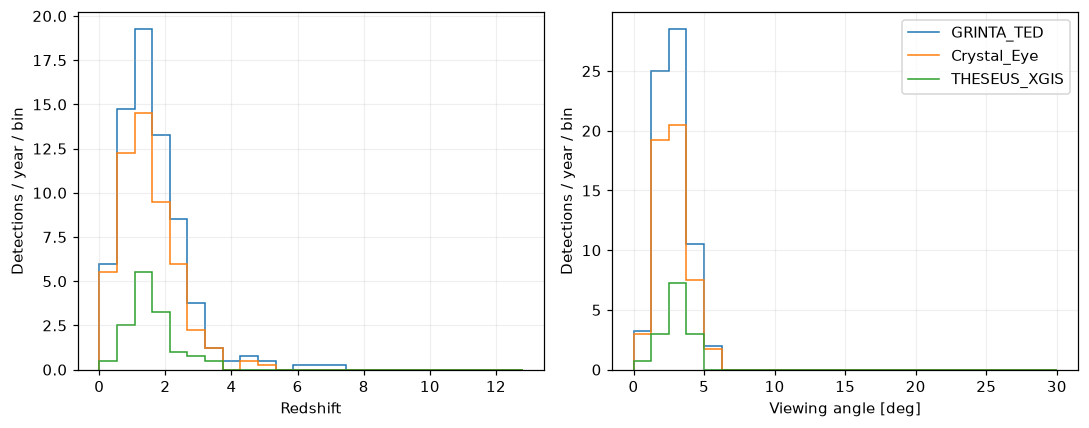

In [61]:
display(pd.DataFrame([asdict(instrument) for instrument in PROMPT]))
events = fp.select_prompt(catalogue, instruments=PROMPT, seed=SEED, max_peak_time_s=MAX_PEAK_TIME_S)
prompt_table = fp.prompt_summary(events, N_YEARS, instruments=PROMPT)
display(prompt_table)
prompt_table.to_csv(OUTPUT_DIR / 'prompt_rates.csv', index=False)
events.to_csv(OUTPUT_DIR / 'catalogue_prompt.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bins = {'z': np.linspace(0, events.z.max(), 25),
        'theta_v_deg': np.linspace(0, THETA_V_MAX_DEG, 25)}
for instrument in PROMPT:
    selected = events[f'prompt_{instrument.name}']
    for ax, column in zip(axes, ('z', 'theta_v_deg')):
        counts, edges = np.histogram(events.loc[selected, column], bins=bins[column])
        ax.stairs(counts / N_YEARS, edges, label=instrument.name)
axes[0].set(xlabel='Redshift', ylabel='Detections / year / bin')
axes[1].set(xlabel='Viewing angle [deg]', ylabel='Detections / year / bin')
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'prompt_distributions.pdf')
plt.show()

## 5. Joint GW detections and localizations

Run GWFish only for events detected in prompt emission by at least one instrument.
Sources shared by instruments are calculated once. For each instrument, count how
many of its prompt events pass SNR > 8, then the GW localization cuts.

Use the catalogue's redshift and viewing angle, and add the tutorial BNS masses
($1.33\pm0.09\,M_\odot$), sky position, polarization and coalescence time.
The networks assume all detectors are operational.

XGIS imaging benchmarks are ≤7 arcmin for 50% and ≤15 arcmin for 90% of triggered sGRBs.

In [62]:
prompt_columns = [f'prompt_{instrument.name}' for instrument in PROMPT]
prompt_events = events.loc[events[prompt_columns].any(axis=1)].copy()
print(f'{len(prompt_events):,} distinct prompt events for GWFish')

binaries = fp.binary_parameters(prompt_events, seed=SEED)
detector_names = sorted({detector for network in NETWORKS.values() for detector in network})
gw_config = fp.resolve_gw_config(
    ROOT / 'Tutorials' / 'configs' / 'coba.yaml', ROOT / 'Tutorials' / 'psds',
    OUTPUT_DIR / 'detectors.yaml', detector_names)
gw_results = fp.run_gw(binaries, NETWORKS, gw_config, waveform=WAVEFORM,
                       threshold=GW_SNR_THRESHOLD, n_jobs=N_JOBS)
joint_table = fp.joint_summary(prompt_events, gw_results, N_YEARS, instruments=PROMPT,
                                localization_cuts=LOCALIZATION_CUTS_DEG2)
display(joint_table)
joint_table.to_csv(OUTPUT_DIR / 'joint_prompt_rates.csv', index=False)
pd.concat([prompt_events, binaries.add_prefix('bns_'), gw_results], axis=1).to_csv(
    OUTPUT_DIR / 'events_prompt_gw.csv', index=False)

441 distinct prompt events for GWFish
GWFish: 441 sources, 6 detectors
  Asharp: 20 GW detections


  3%|▎         | 1/37 [00:00<00:04,  8.84it/s]

  ET_2L: 293 GW detections


  0%|          | 0/216 [00:00<?, ?it/s]

  ET_triangle: 216 GW detections


100%|██████████| 216/216 [00:15<00:00, 13.62it/s]


,instrument,network,count,rate_per_yr,prompt_count,prompt_per_yr,gw_detection_fraction,median_z,z_90th_percentile,median_viewing_angle_deg,...,localized_le_1_deg2_count,localized_le_1_deg2_per_yr,localized_le_10_deg2_count,localized_le_10_deg2_per_yr,localized_le_100_deg2_count,localized_le_100_deg2_per_yr,localized_le_1000_deg2_count,localized_le_1000_deg2_per_yr,em_position_arcmin_benchmark,em_position_fraction_requirement
0,GRINTA_TED,Asharp,15,3.75,277,69.25,0.054152,0.340144,0.438884,3.803331,...,0,0.0,0,0.00,1,0.25,15,3.75,NaN,NaN
1,Crystal_Eye,Asharp,11,2.75,208,52.00,0.052885,0.320408,0.362526,3.696503,...,0,0.0,0,0.00,1,0.25,11,2.75,NaN,NaN
2,THESEUS_XGIS,Asharp,1,0.25,56,14.00,0.017857,0.286671,0.286671,4.170612,...,0,0.0,0,0.00,0,0.00,1,0.25,15.0,0.9
3,GRINTA_TED,ET_2L,176,44.00,277,69.25,0.635379,1.141893,2.097478,2.803833,...,0,0.0,0,0.00,10,2.50,71,17.75,NaN,NaN
4,Crystal_Eye,ET_2L,153,38.25,208,52.00,0.735577,1.131753,2.167323,2.814541,...,0,0.0,1,0.25,9,2.25,64,16.00,NaN,NaN
5,THESEUS_XGIS,ET_2L,37,9.25,56,14.00,0.660714,1.285681,1.942655,3.032930,...,0,0.0,0,0.00,1,0.25,13,3.25,15.0,0.9
6,GRINTA_TED,ET_triangle,126,31.50,277,69.25,0.454874,0.950996,1.609088,3.019598,...,0,0.0,0,0.00,3,0.75,18,4.50,NaN,NaN
7,Crystal_Eye,ET_triangle,114,28.50,208,52.00,0.548077,0.975749,1.844884,2.802151,...,0,0.0,1,0.25,3,0.75,16,4.00,NaN,NaN
8,THESEUS_XGIS,ET_triangle,29,7.25,56,14.00,0.517857,1.211386,1.773188,3.319368,...,0,0.0,0,0.00,0,0.00,2,0.50,15.0,0.9


### Detection and localization plots

Compare all prompt detections, the SNR > 8 subset, and the localized joint subset,
as in Tutorial 4. The distributions use the same redshift bins and annual normalization.

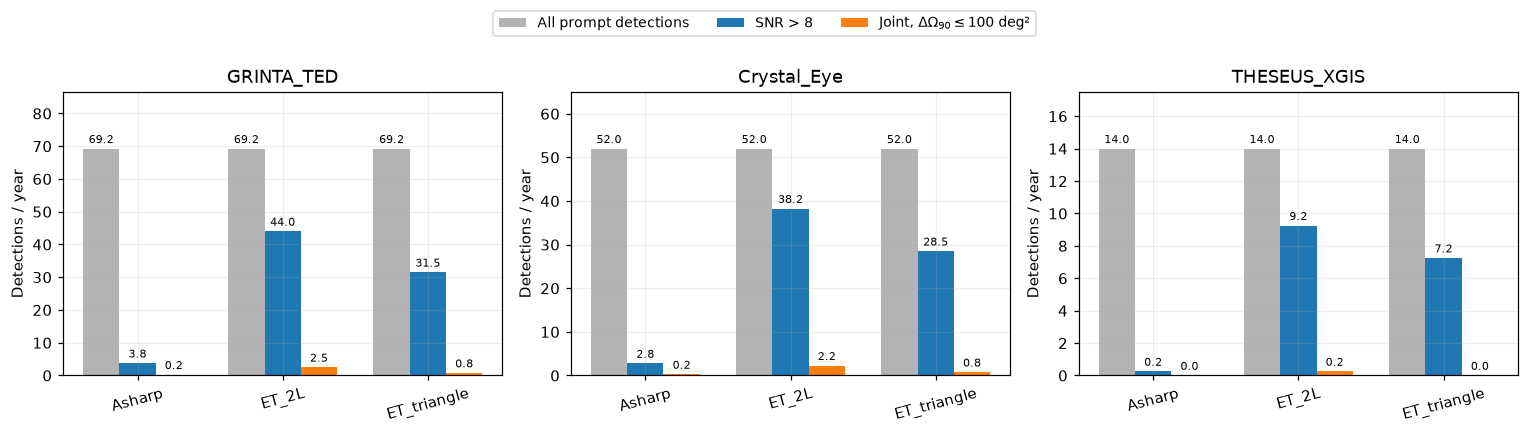

In [63]:
cut = LOCALIZATION_PLOT_CUT_DEG2
fig, axes = plt.subplots(1, len(PROMPT), figsize=(14, 4), squeeze=False)
for ax, instrument in zip(axes[0], PROMPT):
    rows = joint_table[joint_table.instrument == instrument.name].set_index('network').loc[list(NETWORKS)]
    x = np.arange(len(rows))
    stages = [(rows.prompt_per_yr, 'All prompt detections', '0.7'),
              (rows.rate_per_yr, f'SNR > {GW_SNR_THRESHOLD:g}', 'C0'),
              (rows[f'localized_le_{cut:g}_deg2_per_yr'],
               rf'Joint, $\Delta\Omega_{{90}}\leq {cut:g}$ deg²', 'C1')]
    for offset, (rates, label, color) in zip((-0.25, 0, 0.25), stages):
        bars = ax.bar(x + offset, rates, width=0.25, label=label, color=color)
        ax.bar_label(bars, fmt='%.1f', fontsize=7, padding=2)
    ax.set_xticks(x, rows.index, rotation=15)
    ax.set(title=instrument.name, ylabel='Detections / year')
    ax.margins(y=0.25)
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc='upper center',
           bbox_to_anchor=(0.5, 0.99), ncol=3, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.88))
fig.savefig(OUTPUT_DIR / 'joint_detection_stages.pdf')
plt.show()

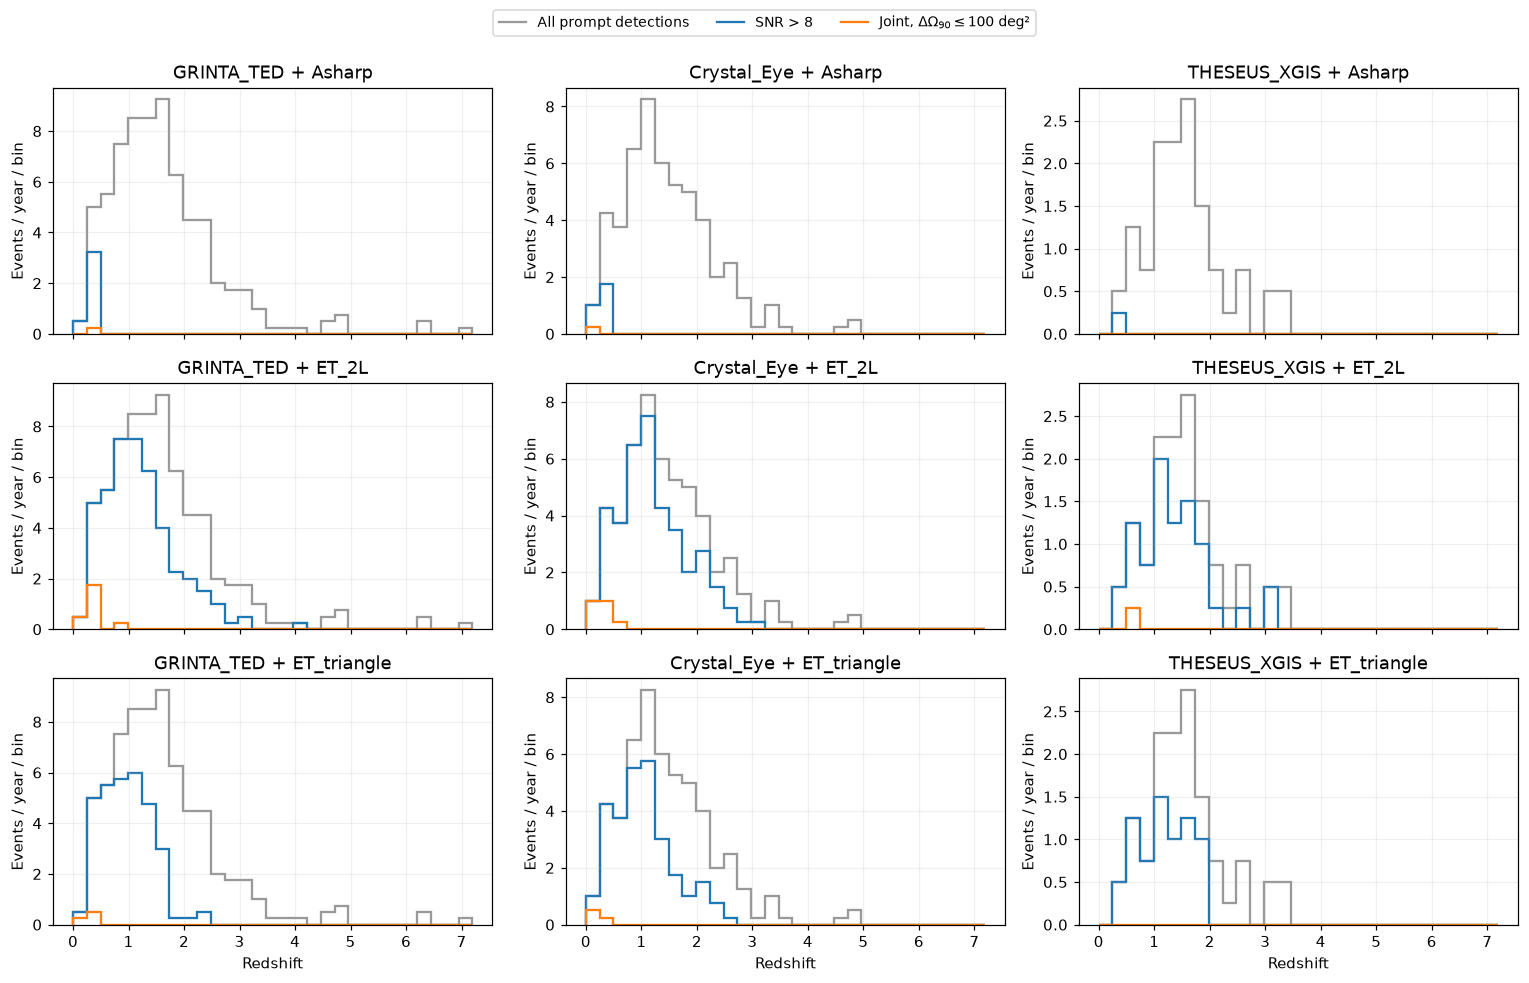

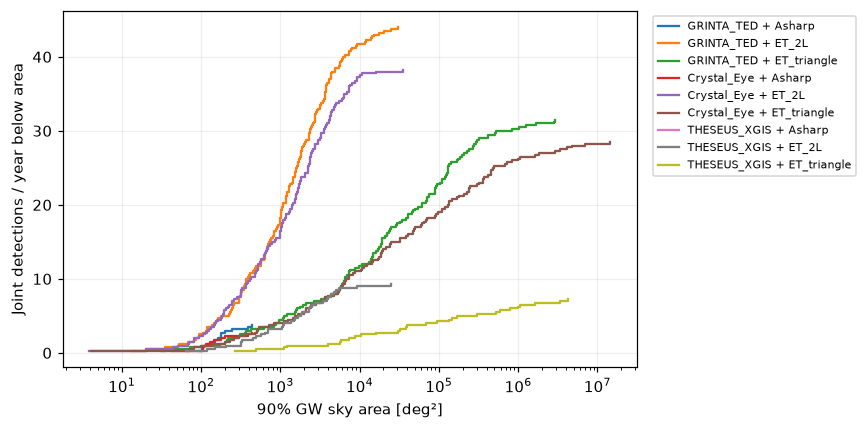

In [64]:
redshift_bins = np.linspace(0, prompt_events.z.max() + 0.1, 30)
fig, axes = plt.subplots(len(NETWORKS), len(PROMPT),
                         figsize=(14, 3 * len(NETWORKS)), sharex=True, squeeze=False)
for row, network in enumerate(NETWORKS):
    for ax, instrument in zip(axes[row], PROMPT):
        gamma = prompt_events[f'prompt_{instrument.name}']
        joint = gamma & gw_results[f'gw_{network}']
        area = gw_results[f'area90_{network}_deg2']
        localized = joint & (area > 0) & (area <= cut)
        for mask, label, color in [(gamma, 'All prompt detections', '0.6'),
                                   (joint, f'SNR > {GW_SNR_THRESHOLD:g}', 'C0'),
                                   (localized, rf'Joint, $\Delta\Omega_{{90}}\leq {cut:g}$ deg²', 'C1')]:
            counts, edges = np.histogram(prompt_events.loc[mask, 'z'], bins=redshift_bins)
            ax.stairs(counts / N_YEARS, edges, label=label, color=color, linewidth=1.5)
        ax.set(title=f'{instrument.name} + {network}', ylabel='Events / year / bin')
for ax in axes[-1]:
    ax.set_xlabel('Redshift')
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc='upper center',
           bbox_to_anchor=(0.5, 0.995), ncol=3, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(OUTPUT_DIR / 'redshift_localization_cuts.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
for instrument in PROMPT:
    for network in NETWORKS:
        joint = prompt_events[f'prompt_{instrument.name}'] & gw_results[f'gw_{network}']
        area = gw_results.loc[joint, f'area90_{network}_deg2'].dropna().sort_values()
        if len(area):
            ax.step(area, np.arange(1, len(area) + 1) / N_YEARS, where='post',
                    label=f'{instrument.name} + {network}')
ax.set(xscale='log', xlabel='90% GW sky area [deg²]', ylabel='Joint detections / year below area')
if ax.get_legend_handles_labels()[0]:
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'joint_localization_cumulative.pdf')
plt.show()

## 6. X-ray afterglows

Retain prompt events with viewing angles ≤10° for the afterglow catalogue.
VegasAfterglow uses the same source's $E_{\rm iso}$, redshift and viewing angle,
with the 5° top-hat setup. The density, $\epsilon_B$ and Lorentz factor are drawn
once per source and reused across the comparisons.

Follow the supplied afterglow code: scan the imager's exposures around the light-curve
peak available after the alert and response delay. HXI uses 5–30 keV; SXI uses
0.3–5 keV with the [Yellow Book](https://sci.esa.int/documents/34375/36249/Theseus_YB_final.pdf)
sensitivities. `followup_fraction=1` assumes follow-up is arranged.

Report prompt events with detectable afterglows, their GW-detected subset, and
the subset localized within the selected GW sky area.

,name,band_keV,flux_unit,exposures_s,limits,followup_fraction,position_arcmin
0,GRINTA_HXI,"(5.0, 30.0)",ph,"(10.0, 100.0, 1000.0, 10000.0, 100000.0)","(0.03794733192202055, 0.011999999999999999, 0....",1.0,NaN
1,THESEUS_SXI,"(0.3, 5.0)",erg,"(100.0, 1500.0)","(1e-10, 1.8e-11)",1.0,2.0


VegasAfterglow: 441 sources


,prompt_instrument,imager,network,delay_s,localization_cut_deg2,followup_fraction,afterglow_position_arcmin,prompt_afterglow_count,prompt_afterglow_per_yr,prompt_gw_afterglow_count,prompt_gw_afterglow_per_yr,localized_prompt_gw_afterglow_count,localized_prompt_gw_afterglow_per_yr
0,GRINTA_TED,GRINTA_HXI,Asharp,0.0,100.0,1.0,NaN,3,0.75,1,0.25,0,0.0
1,GRINTA_TED,GRINTA_HXI,ET_2L,0.0,100.0,1.0,NaN,3,0.75,3,0.75,0,0.0
2,GRINTA_TED,GRINTA_HXI,ET_triangle,0.0,100.0,1.0,NaN,3,0.75,3,0.75,0,0.0
3,Crystal_Eye,GRINTA_HXI,Asharp,0.0,100.0,1.0,NaN,1,0.25,1,0.25,0,0.0
4,Crystal_Eye,GRINTA_HXI,ET_2L,0.0,100.0,1.0,NaN,1,0.25,1,0.25,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Crystal_Eye,THESEUS_SXI,ET_2L,3600.0,100.0,1.0,2.0,0,0.00,0,0.00,0,0.0
68,Crystal_Eye,THESEUS_SXI,ET_triangle,3600.0,100.0,1.0,2.0,0,0.00,0,0.00,0,0.0
69,THESEUS_XGIS,THESEUS_SXI,Asharp,3600.0,100.0,1.0,2.0,0,0.00,0,0.00,0,0.0
70,THESEUS_XGIS,THESEUS_SXI,ET_2L,3600.0,100.0,1.0,2.0,0,0.00,0,0.00,0,0.0


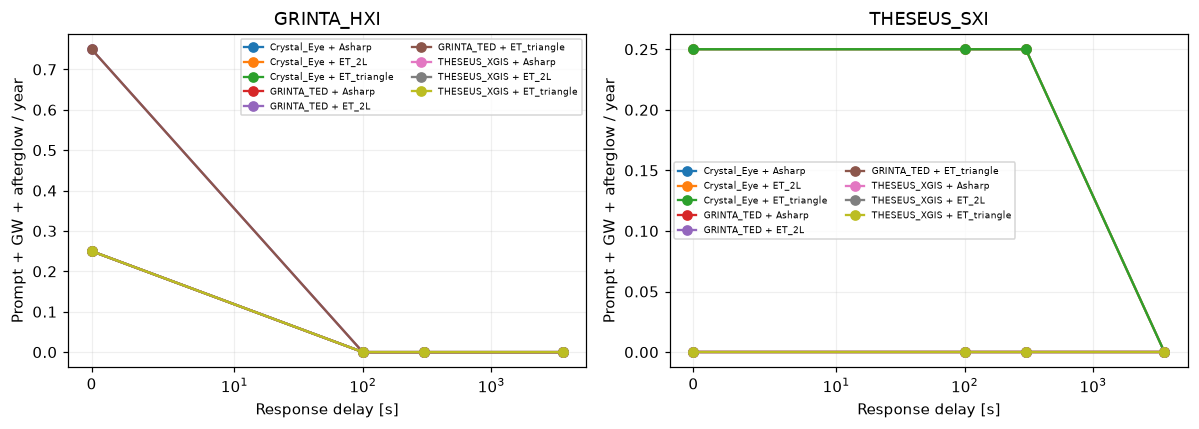

In [65]:
afterglow_catalogue = prompt_events.loc[
    prompt_events.theta_v_deg <= AFTERGLOW_MAX_VIEWING_ANGLE_DEG].copy()
afterglow_catalogue.to_csv(OUTPUT_DIR / 'afterglow_catalogue.csv', index=False)
display(pd.DataFrame([asdict(imager) for imager in AFTERGLOW_IMAGERS]))
microphysics = fp.afterglow_parameters(afterglow_catalogue, seed=SEED)
afterglow_events = fp.run_afterglow(
    afterglow_catalogue, microphysics, instruments=AFTERGLOW_IMAGERS,
    delays=RESPONSE_DELAYS_S, theta_core_deg=AFTERGLOW_THETA_CORE_DEG, n_jobs=N_JOBS)
afterglow_table = fp.afterglow_summary(
    prompt_events, gw_results, afterglow_events, N_YEARS,
    instruments=AFTERGLOW_IMAGERS, prompt_instruments=PROMPT,
    delays=RESPONSE_DELAYS_S, localization_cut=LOCALIZATION_PLOT_CUT_DEG2, seed=SEED)
display(afterglow_table)
afterglow_table.to_csv(OUTPUT_DIR / 'afterglow_rates.csv', index=False)
afterglow_events.to_csv(OUTPUT_DIR / 'afterglow_events.csv', index=False)
microphysics.assign(event_id=afterglow_catalogue.event_id).to_csv(
    OUTPUT_DIR / 'afterglow_parameters.csv', index=False)

fig, axes = plt.subplots(1, len(AFTERGLOW_IMAGERS), figsize=(11, 4), squeeze=False)
for ax, imager in zip(axes[0], AFTERGLOW_IMAGERS):
    rows = afterglow_table[afterglow_table.imager == imager.name]
    for (instrument, network), group in rows.groupby(['prompt_instrument', 'network']):
        group = group.sort_values('delay_s')
        ax.plot(group.delay_s, group.prompt_gw_afterglow_per_yr, 'o-',
                label=f'{instrument} + {network}')
    ax.set(xlabel='Response delay [s]', ylabel='Prompt + GW + afterglow / year', title=imager.name)
    ax.set_xscale('symlog', linthresh=10)
    ax.legend(fontsize=6, ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'afterglow_rates.pdf')
plt.show()

## 7. Numbers for the chapter

Combine the prompt and joint rates, GW localizations and afterglow scenarios in one table.

In [ ]:
chapter_numbers = joint_table.rename(columns={
    'instrument': 'prompt_instrument', 'count': 'prompt_joint_count',
    'rate_per_yr': 'prompt_joint_per_yr'})
chapter_numbers = chapter_numbers.merge(afterglow_table, on=['prompt_instrument', 'network'])
chapter_numbers.to_csv(OUTPUT_DIR / 'chapter_numbers.csv', index=False)
display(chapter_numbers)
print(f'Saved catalogues, rate tables and figures in {OUTPUT_DIR}')